In [1]:
import joblib

model_path = r"C:\Users\sushm\OneDrive\Desktop\Digital-Wellbeing-Analytics\random_forest_final_model.pkl"

final_model = joblib.load(model_path)

print("Final model loaded successfully!")

Final model loaded successfully!


In [3]:
def predict_addiction(user_data):
    prediction = final_model.predict(user_data)

    if prediction[0] == 1:
        return "Likely Addicted"
    else:
        return "Likely Not Addicted"

In [4]:
import pandas as pd

sample_user = pd.DataFrame({
    "age": [21],
    "gender": ["Female"],
    "daily_screen_time_hours": [8.0],
    "social_media_hours": [4.0],
    "gaming_hours": [2.0],
    "work_study_hours": [4.0],
    "sleep_hours": [7.0],
    "notifications_per_day": [150],
    "app_opens_per_day": [100],
    "weekend_screen_time": [10.0],
    "stress_level": ["High"],
    "academic_work_impact": ["Yes"],
    "total_leisure_hours": [6.0],
    "screen_to_sleep_ratio": [8.0 / 7.0],
    "weekend_screen_time_increase": [2.0],
    "notification_intensity": [150 / 100],
    "productive_time_ratio": [4.0 / (4.0 + 8.0)]
})

sample_user

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,total_leisure_hours,screen_to_sleep_ratio,weekend_screen_time_increase,notification_intensity,productive_time_ratio
0,21,Female,8.0,4.0,2.0,4.0,7.0,150,100,10.0,High,Yes,6.0,1.142857,2.0,1.5,0.333333


In [5]:
result = predict_addiction(sample_user)

print("Prediction for the sample user:", result)

Prediction for the sample user: Likely Addicted


In [6]:
probabilities = final_model.predict_proba(sample_user)[0]

print("Probability of being Not Addicted:", round(probabilities[0] * 100, 2), "%")
print("Probability of being Addicted:", round(probabilities[1] * 100, 2), "%")

Probability of being Not Addicted: 12.0 %
Probability of being Addicted: 88.0 %


In [10]:
def detailed_prediction(user_data):
    prediction = final_model.predict(user_data)[0]
    probabilities = final_model.predict_proba(user_data)[0]

    if prediction == 1:
        status = "Likely Addicted"
    else:
        status = "Likely Not Addicted"

    print("Prediction Result:", status)
    print("Not Addicted Probability:", round(probabilities[0] * 100, 2), "%")
    print("Addicted Probability:", round(probabilities[1] * 100, 2), "%")

In [9]:
detailed_prediction(sample_user)

Prediction Result: Likely Addicted
Not Addicted Probability: 12.0 %
Addicted Probability: 88.0 %


In [11]:
custom_user = pd.DataFrame({
    "age": [int(input("Enter age: "))],
    "gender": [input("Enter gender (Male/Female/Other): ")],
    "daily_screen_time_hours": [float(input("Enter daily screen time in hours: "))],
    "social_media_hours": [float(input("Enter social media usage in hours: "))],
    "gaming_hours": [float(input("Enter gaming hours: "))],
    "work_study_hours": [float(input("Enter work/study hours: "))],
    "sleep_hours": [float(input("Enter sleep hours: "))],
    "notifications_per_day": [int(input("Enter notifications per day: "))],
    "app_opens_per_day": [int(input("Enter app opens per day: "))],
    "weekend_screen_time": [float(input("Enter weekend screen time in hours: "))],
    "stress_level": [input("Enter stress level (High/Medium/Low): ")],
    "academic_work_impact": [input("Academic/work impact (Yes/No): ")],
})

custom_user["total_leisure_hours"] = (
    custom_user["social_media_hours"] + custom_user["gaming_hours"]
)

custom_user["screen_to_sleep_ratio"] = (
    custom_user["daily_screen_time_hours"] / custom_user["sleep_hours"]
)

custom_user["weekend_screen_time_increase"] = (
    custom_user["weekend_screen_time"] -
    custom_user["daily_screen_time_hours"]
)

custom_user["notification_intensity"] = (
    custom_user["notifications_per_day"] /
    custom_user["app_opens_per_day"]
)

custom_user["productive_time_ratio"] = (
    custom_user["work_study_hours"] /
    (
        custom_user["work_study_hours"] +
        custom_user["daily_screen_time_hours"]
    )
)

custom_user

Enter age:  21
Enter gender (Male/Female/Other):  Female
Enter daily screen time in hours:  8
Enter social media usage in hours:  4
Enter gaming hours:  2
Enter work/study hours:  4
Enter sleep hours:  7
Enter notifications per day:  150
Enter app opens per day:  100
Enter weekend screen time in hours:  10
Enter stress level (High/Medium/Low):  High
Academic/work impact (Yes/No):  Yes


,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,total_leisure_hours,screen_to_sleep_ratio,weekend_screen_time_increase,notification_intensity,productive_time_ratio
0,21,Female,8.0,4.0,2.0,4.0,7.0,150,100,10.0,High,Yes,6.0,1.142857,2.0,1.5,0.333333


In [12]:
detailed_prediction(custom_user)

Prediction Result: Likely Addicted
Not Addicted Probability: 12.0 %
Addicted Probability: 88.0 %


In [13]:
custom_prediction = custom_user.copy()

custom_prediction["prediction"] = final_model.predict(custom_user)
custom_prediction["not_addicted_probability"] = (
    final_model.predict_proba(custom_user)[:, 0]
)
custom_prediction["addicted_probability"] = (
    final_model.predict_proba(custom_user)[:, 1]
)

prediction_path = r"C:\Users\sushm\OneDrive\Desktop\Digital-Wellbeing-Analytics\data\processed\custom_user_prediction.csv"

custom_prediction.to_csv(prediction_path, index=False)

print("Prediction result saved successfully!")
print("Saved location:", prediction_path)

Prediction result saved successfully!
Saved location: C:\Users\sushm\OneDrive\Desktop\Digital-Wellbeing-Analytics\data\processed\custom_user_prediction.csv


In [14]:
saved_prediction = pd.read_csv(
    r"C:\Users\sushm\OneDrive\Desktop\Digital-Wellbeing-Analytics\data\processed\custom_user_prediction.csv"
)

saved_prediction

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,total_leisure_hours,screen_to_sleep_ratio,weekend_screen_time_increase,notification_intensity,productive_time_ratio,prediction,not_addicted_probability,addicted_probability
0,21,Female,8.0,4.0,2.0,4.0,7.0,150,100,10.0,High,Yes,6.0,1.142857,2.0,1.5,0.333333,1,0.12,0.88


In [15]:
prediction_value = int(custom_prediction["prediction"].iloc[0])
addicted_probability = custom_prediction["addicted_probability"].iloc[0] * 100
not_addicted_probability = custom_prediction["not_addicted_probability"].iloc[0] * 100

if prediction_value == 1:
    final_status = "Likely Addicted"
else:
    final_status = "Likely Not Addicted"

print("SMARTPHONE ADDICTION PREDICTION SUMMARY")
print("----------------------------------------")
print("Final Prediction:", final_status)
print("Addicted Probability:", round(addicted_probability, 2), "%")
print("Not Addicted Probability:", round(not_addicted_probability, 2), "%")

SMARTPHONE ADDICTION PREDICTION SUMMARY
----------------------------------------
Final Prediction: Likely Addicted
Addicted Probability: 88.0 %
Not Addicted Probability: 12.0 %


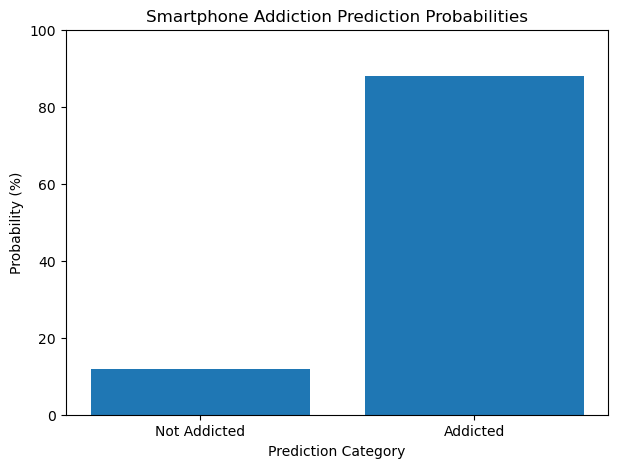

In [16]:
import matplotlib.pyplot as plt

labels = ["Not Addicted", "Addicted"]
probability_values = [
    not_addicted_probability,
    addicted_probability
]

plt.figure(figsize=(7, 5))

plt.bar(labels, probability_values)

plt.xlabel("Prediction Category")
plt.ylabel("Probability (%)")
plt.title("Smartphone Addiction Prediction Probabilities")
plt.ylim(0, 100)
plt.show()

In [17]:
print("CUSTOM USER DETAILS")
print("-------------------")

for column in custom_user.columns:
    print(column, ":", custom_user[column].iloc[0])

CUSTOM USER DETAILS
-------------------
age : 21
gender : Female
daily_screen_time_hours : 8.0
social_media_hours : 4.0
gaming_hours : 2.0
work_study_hours : 4.0
sleep_hours : 7.0
notifications_per_day : 150
app_opens_per_day : 100
weekend_screen_time : 10.0
stress_level : High
academic_work_impact : Yes
total_leisure_hours : 6.0
screen_to_sleep_ratio : 1.1428571428571428
weekend_screen_time_increase : 2.0
notification_intensity : 1.5
productive_time_ratio : 0.3333333333333333


In [18]:
print("MODULE 6 COMPLETION SUMMARY")
print("---------------------------")
print("1. Loaded the trained Random Forest model.")
print("2. Created a prediction function.")
print("3. Tested the model with sample user data.")
print("4. Displayed addiction probabilities.")
print("5. Created a custom user-input prediction system.")
print("6. Saved the prediction results to a CSV file.")
print("7. Visualized the prediction probabilities.")

print("\nModule 6 completed successfully!")

MODULE 6 COMPLETION SUMMARY
---------------------------
1. Loaded the trained Random Forest model.
2. Created a prediction function.
3. Tested the model with sample user data.
4. Displayed addiction probabilities.
5. Created a custom user-input prediction system.
6. Saved the prediction results to a CSV file.
7. Visualized the prediction probabilities.

Module 6 completed successfully!


In [19]:
print("Notebook name: 06_prediction_system.ipynb")
print("Project folder: Digital-Wellbeing-Analytics")
print("Prediction system completed and documented.")

Notebook name: 06_prediction_system.ipynb
Project folder: Digital-Wellbeing-Analytics
Prediction system completed and documented.
